# PowerGridReconfig - topology switching visualization

Этот notebook визуализирует текущий pipeline ветки `integrate-gridfm-datakit`:

1. загрузка аварийных сценариев из `gridfm-datakit`;
2. анализ перегрузок ветвей и напряжений;
3. анализ transition dataset;
4. выбор лучшего topology switching action;
5. пересчет power flow через PYPOWER backend;
6. визуальное сравнение сети **до** и **после** переключения.

Notebook рассчитан на запуск из корня репозитория или из папки `notebooks/`.

## 1. Подготовка окружения

Перед запуском убедись, что данные уже сгенерированы:

```powershell
gridfm_datakit generate configs/gridfm_case118.yaml

python -m scripts.generate_transitions `
  data/gridfm_smoke/case118_ieee/raw `
  --output data/gridfm_transitions/transitions_serious_top30.csv `
  --top-k 30 `
  --min-start-loading 110
```

Если не установлены библиотеки для notebook:

```powershell
pip install notebook matplotlib networkx pandas numpy
```

In [2]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd


def find_project_root(start: Path | None = None) -> Path:
    """
    Find repository root by looking for the grid_topology_ai package.
    Works both when the notebook is opened from project root and from notebooks/.
    """
    current = Path.cwd() if start is None else start.resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "grid_topology_ai").exists():
            return candidate

    raise RuntimeError(
        "Cannot find project root. Open this notebook from inside the PowerGridReconfig repository."
    )


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

RAW_DIR = PROJECT_ROOT / "data" / "gridfm_smoke" / "case118_ieee" / "raw"
SERIOUS_TRANSITIONS_CSV = PROJECT_ROOT / "data" / "gridfm_transitions" / "transitions_serious_top30.csv"
TOP30_TRANSITIONS_CSV = PROJECT_ROOT / "data" / "gridfm_transitions" / "transitions_top30_v3.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw GridFM directory: {RAW_DIR}")
print(f"Serious transitions: {SERIOUS_TRANSITIONS_CSV}")

Project root: D:\проекты\PowerGridReconfig
Raw GridFM directory: D:\проекты\PowerGridReconfig\data\gridfm_smoke\case118_ieee\raw
Serious transitions: D:\проекты\PowerGridReconfig\data\gridfm_transitions\transitions_serious_top30.csv


In [3]:
from grid_topology_ai.data_adapter import (
    BRANCH_FEATURE_COLUMNS,
    BUS_FEATURE_COLUMNS,
    GridFMAdapter,
)
from grid_topology_ai.action_space import GridFMActionSpace
from grid_topology_ai.pypower_backend import GridFMPowerFlowBackend
from grid_topology_ai.reward import GridFMReward

print("Project imports loaded successfully.")

Project imports loaded successfully.


## 2. Проверка входных данных

In [4]:
required_raw_files = [
    RAW_DIR / "bus_data.parquet",
    RAW_DIR / "branch_data.parquet",
    RAW_DIR / "gen_data.parquet",
]

missing = [path for path in required_raw_files if not path.exists()]

if missing:
    print("Missing required GridFM files:")
    for path in missing:
        print(f"  - {path}")
    print("\nRun gridfm_datakit generate configs/gridfm_case118.yaml first.")
else:
    print("All required GridFM files exist.")

if SERIOUS_TRANSITIONS_CSV.exists():
    transitions_path = SERIOUS_TRANSITIONS_CSV
elif TOP30_TRANSITIONS_CSV.exists():
    transitions_path = TOP30_TRANSITIONS_CSV
else:
    transitions_path = None

print(f"Selected transitions file: {transitions_path}")

All required GridFM files exist.
Selected transitions file: D:\проекты\PowerGridReconfig\data\gridfm_transitions\transitions_serious_top30.csv


## 3. Загрузка сценариев GridFM

In [5]:
adapter = GridFMAdapter(RAW_DIR)

summary = adapter.build_summary()
summary = summary.sort_values("scenario").reset_index(drop=True)

print(f"Total scenarios: {len(summary)}")
display(summary.head())

useful_ids = adapter.useful_scenario_ids()
print(f"Useful scenario IDs: {useful_ids}")

Total scenarios: 25


,scenario,load_scenario_idx,num_buses,num_branches,num_generators,total_load_p_mw,total_load_q_mvar,total_gen_p_mw,max_loading_percent,mean_loading_percent,...,num_hard_overloaded_branches,min_vm_pu,max_vm_pu,num_low_voltage_buses,num_high_voltage_buses,total_low_voltage_violation,total_high_voltage_violation,total_voltage_violation,num_outaged_branches,outaged_branch_ids
0,0,0.0,118,186,54,4086.433393,1367.72851,4211.719427,100.038275,27.782501,...,0,1.000612,1.060000,0,4,0.0,6.913590e-08,6.913590e-08,1,[156]
1,1,0.0,118,186,54,4086.433393,1367.72851,4210.518752,101.266669,27.605711,...,0,1.000612,1.060063,0,4,0.0,6.323049e-05,6.323049e-05,1,[110]
2,2,0.0,118,186,54,4086.433393,1367.72851,4215.294666,132.445510,27.770371,...,1,1.000612,1.060000,0,4,0.0,5.387177e-08,5.387177e-08,1,[163]
3,3,0.0,118,186,54,4086.433393,1367.72851,4211.665705,99.999999,27.806661,...,0,0.996552,1.060000,0,5,0.0,3.726091e-07,3.726091e-07,1,[72]
4,4,0.0,118,186,54,4086.433393,1367.72851,4212.422795,100.076015,27.747639,...,0,1.000612,1.060015,0,4,0.0,1.542487e-05,1.542487e-05,1,[14]


Useful scenario IDs: [0, 1, 2, 4, 7, 11, 13, 14, 15, 24]


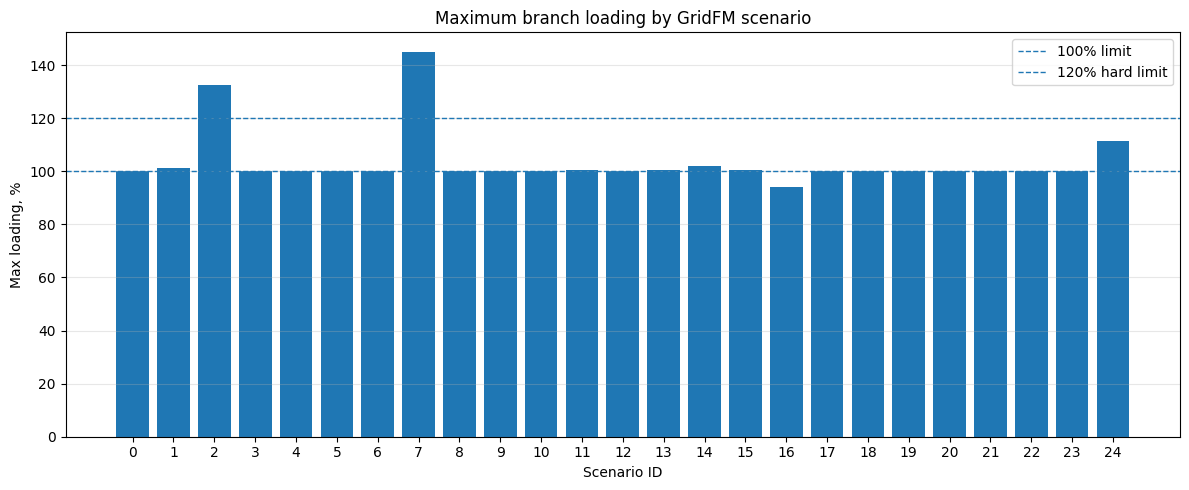

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(summary["scenario"].astype(str), summary["max_loading_percent"])
ax.axhline(100.0, linestyle="--", linewidth=1, label="100% limit")
ax.axhline(120.0, linestyle="--", linewidth=1, label="120% hard limit")

ax.set_title("Maximum branch loading by GridFM scenario")
ax.set_xlabel("Scenario ID")
ax.set_ylabel("Max loading, %")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

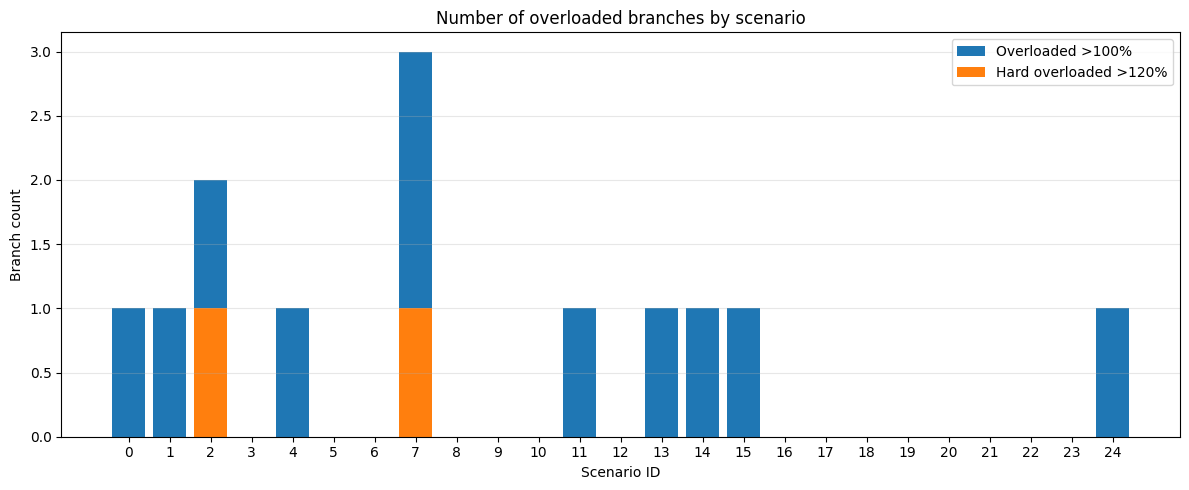

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(summary["scenario"].astype(str), summary["num_overloaded_branches"], label="Overloaded >100%")
ax.bar(summary["scenario"].astype(str), summary["num_hard_overloaded_branches"], label="Hard overloaded >120%")

ax.set_title("Number of overloaded branches by scenario")
ax.set_xlabel("Scenario ID")
ax.set_ylabel("Branch count")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Загрузка transition dataset

In [8]:
if transitions_path is None:
    raise FileNotFoundError(
        "No transition CSV found. Generate it with scripts/generate_transitions.py first."
    )

transitions = pd.read_csv(transitions_path)
print(f"Transitions file: {transitions_path}")
print(f"Rows: {len(transitions)}")
print(f"Scenarios: {transitions['scenario_id'].nunique()}")

display(transitions.head())

Transitions file: D:\проекты\PowerGridReconfig\data\gridfm_transitions\transitions_serious_top30.csv
Rows: 93
Scenarios: 3


,transition_id,scenario_id,action_id,action_type,branch_id,branch_pos,power_flow_success,reward,done,before_max_loading,...,after_num_overloaded,before_num_hard_overloaded,after_num_hard_overloaded,before_voltage_penalty,after_voltage_penalty,before_penalty,after_penalty,improvement,switching_penalty,message
0,0,2,0,do_nothing,NaN,NaN,True,0.000000,False,132.44551,...,2,1,1,5.387177e-08,5.387177e-08,177.383541,177.383541,0.000000,0.0,Do nothing.
1,1,2,163,switch_off_branch,162.0,162.0,True,-1497.094707,False,132.44551,...,3,1,2,5.387177e-08,1.895737e-03,177.383541,1673.478249,-1496.094707,1.0,Power flow converged.
2,2,2,106,switch_off_branch,105.0,105.0,True,-24.093801,False,132.44551,...,2,1,1,5.387177e-08,1.844302e-03,177.383541,200.477342,-23.093801,1.0,Power flow converged.
3,3,2,155,switch_off_branch,154.0,154.0,True,-1.913780,False,132.44551,...,2,1,1,5.387177e-08,1.897164e-03,177.383541,178.297321,-0.913780,1.0,Power flow converged.
4,4,2,105,switch_off_branch,104.0,104.0,True,-86.985385,False,132.44551,...,2,1,2,5.387177e-08,1.843122e-03,177.383541,263.368926,-85.985385,1.0,Power flow converged.


In [9]:
print("Reward statistics:")
display(transitions["reward"].describe())

print("\nPower flow success:")
display(transitions["power_flow_success"].value_counts(dropna=False))

print("\nDone:")
display(transitions["done"].value_counts(dropna=False))

print("\nReward sign counts:")
reward_signs = pd.Series(
    {
        "positive": int((transitions["reward"] > 0).sum()),
        "zero": int((transitions["reward"] == 0).sum()),
        "negative": int((transitions["reward"] < 0).sum()),
    }
)
display(reward_signs)

Reward statistics:


count      93.000000
mean     -141.109817
std       510.180792
min     -4156.134742
25%       -43.803564
50%        -6.477715
75%        -1.497546
max       170.615881
Name: reward, dtype: float64


Power flow success:


power_flow_success
True     92
False     1
Name: count, dtype: int64


Done:


done
False    91
True      2
Name: count, dtype: int64


Reward sign counts:


positive    15
zero         3
negative    75
dtype: int64

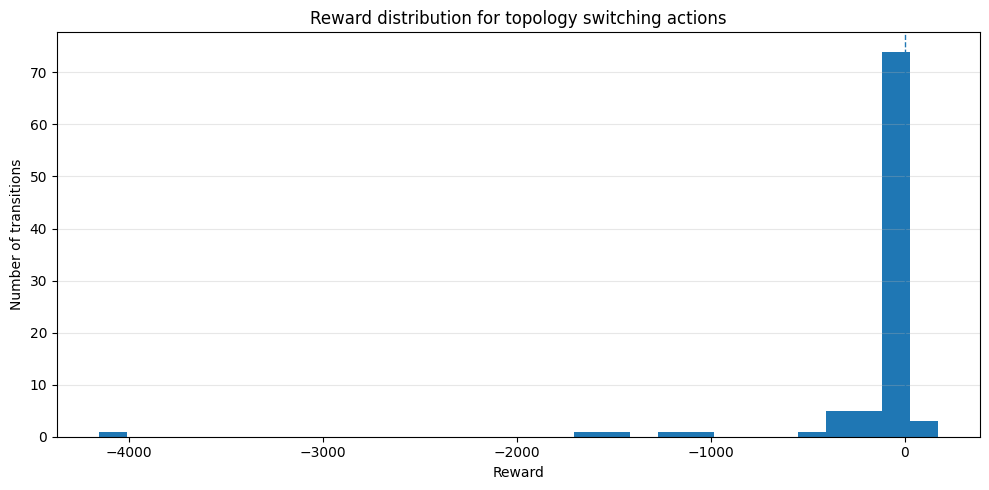

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(transitions["reward"], bins=30)
ax.axvline(0.0, linestyle="--", linewidth=1)

ax.set_title("Reward distribution for topology switching actions")
ax.set_xlabel("Reward")
ax.set_ylabel("Number of transitions")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Лучшее действие для каждого сценария

In [11]:
best_idx = transitions.groupby("scenario_id")["reward"].idxmax()
best_actions = transitions.loc[best_idx].sort_values("scenario_id").reset_index(drop=True)

cols = [
    "scenario_id",
    "action_id",
    "action_type",
    "branch_id",
    "reward",
    "done",
    "before_max_loading",
    "after_max_loading",
    "before_total_overload",
    "after_total_overload",
    "before_num_overloaded",
    "after_num_overloaded",
    "before_num_hard_overloaded",
    "after_num_hard_overloaded",
]

display(best_actions[cols])

,scenario_id,action_id,action_type,branch_id,reward,done,before_max_loading,after_max_loading,before_total_overload,after_total_overload,before_num_overloaded,after_num_overloaded,before_num_hard_overloaded,after_num_hard_overloaded
0,2,174,switch_off_branch,173.0,42.416775,False,132.445510,126.009557,32.577980,26.485435,2,2,1,1
1,7,123,switch_off_branch,122.0,170.615881,False,145.065516,113.173170,54.122749,35.540230,3,5,1,0
2,24,155,switch_off_branch,154.0,81.128416,True,111.516399,99.999999,11.516396,0.000000,1,0,0,0


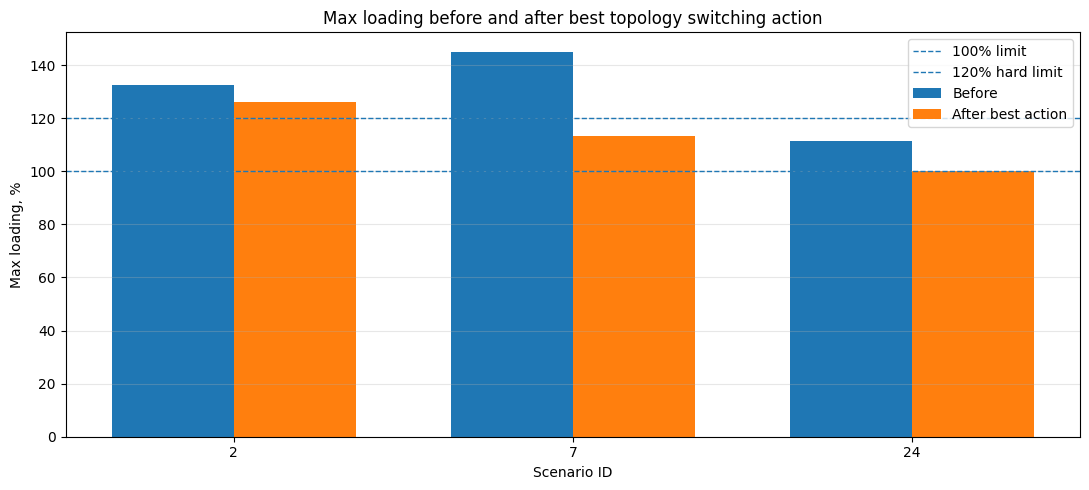

In [12]:
plot_df = best_actions.copy()
x = np.arange(len(plot_df))
width = 0.36

fig, ax = plt.subplots(figsize=(11, 5))

ax.bar(x - width / 2, plot_df["before_max_loading"], width, label="Before")
ax.bar(x + width / 2, plot_df["after_max_loading"], width, label="After best action")

ax.axhline(100.0, linestyle="--", linewidth=1, label="100% limit")
ax.axhline(120.0, linestyle="--", linewidth=1, label="120% hard limit")

ax.set_xticks(x)
ax.set_xticklabels(plot_df["scenario_id"].astype(str))
ax.set_title("Max loading before and after best topology switching action")
ax.set_xlabel("Scenario ID")
ax.set_ylabel("Max loading, %")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Выбор сценария и действия для визуализации

По умолчанию notebook выбирает сценарий с максимальным reward.  
Можно вручную заменить `SCENARIO_ID` и `BRANCH_ID`.

In [13]:
best_transition = transitions.sort_values("reward", ascending=False).iloc[0]

SCENARIO_ID = int(best_transition["scenario_id"])
BRANCH_ID = None if pd.isna(best_transition["branch_id"]) else int(best_transition["branch_id"])

print("Selected transition:")
display(best_transition[cols])

print(f"SCENARIO_ID = {SCENARIO_ID}")
print(f"BRANCH_ID   = {BRANCH_ID}")

Selected transition:


scenario_id                                   7
action_id                                   123
action_type                   switch_off_branch
branch_id                                 122.0
reward                               170.615881
done                                      False
before_max_loading                   145.065516
after_max_loading                     113.17317
before_total_overload                 54.122749
after_total_overload                   35.54023
before_num_overloaded                         3
after_num_overloaded                          5
before_num_hard_overloaded                    1
after_num_hard_overloaded                     0
Name: 32, dtype: object

SCENARIO_ID = 7
BRANCH_ID   = 122


In [14]:
state_before = adapter.build_state(SCENARIO_ID)

backend = GridFMPowerFlowBackend(adapter)
reward_fn = GridFMReward()

if BRANCH_ID is None:
    result = None
    state_after = state_before
    print("Selected action is do_nothing. After-state equals before-state.")
else:
    result = backend.run_power_flow(
        scenario_id=SCENARIO_ID,
        switched_off_branch_id=BRANCH_ID,
    )
    print(f"Power flow success: {result.success}")
    print(f"Message: {result.message}")
    state_after = result.next_state

if state_after is None:
    raise RuntimeError("After-state is None. The selected action did not produce a valid state.")

print("Before metrics:")
display(pd.Series(state_before.metrics))

print("After metrics:")
display(pd.Series(state_after.metrics))

Power flow success: True
Message: Power flow converged.
Before metrics:


num_buses                       118.000000
num_branches                    186.000000
max_loading_percent             145.065516
mean_loading_percent             28.494939
num_overloaded_branches           3.000000
num_hard_overloaded_branches      1.000000
min_vm_pu                         1.003444
max_vm_pu                         1.060019
num_low_voltage_buses             0.000000
num_high_voltage_buses            4.000000
total_low_voltage_violation       0.000000
total_high_voltage_violation      0.000019
total_voltage_violation           0.000019
num_outaged_branches              1.000000
dtype: float64

After metrics:


num_buses                       118.000000
num_branches                    186.000000
max_loading_percent             113.173170
mean_loading_percent             29.384967
num_overloaded_branches           5.000000
num_hard_overloaded_branches      0.000000
min_vm_pu                         1.003444
max_vm_pu                         1.061772
num_low_voltage_buses             0.000000
num_high_voltage_buses            4.000000
total_low_voltage_violation       0.000000
total_high_voltage_violation      0.001772
total_voltage_violation           0.001772
num_outaged_branches              2.000000
dtype: float64

## 7. Визуализация графа сети до и после switching action

Цвет ребра показывает загрузку:

- серый - до 100%;
- оранжевый - 100-120%;
- красный - выше 120%.

Отключенные ветви не рисуются как активные ребра.

In [15]:
def build_visual_graph(state):
    """
    Convert GridFMState to a NetworkX graph for visualization.
    Parallel branches are collapsed visually, but the heaviest loading is kept.
    """
    loading_idx = BRANCH_FEATURE_COLUMNS.index("loading_percent")
    status_idx = BRANCH_FEATURE_COLUMNS.index("br_status")

    graph = nx.Graph()
    graph.add_nodes_from(range(state.bus_features.shape[0]))

    for pos, branch_id in enumerate(state.branch_ids):
        status = float(state.branch_features[pos, status_idx])
        if status <= 0:
            continue

        u = int(state.edge_index[0, pos])
        v = int(state.edge_index[1, pos])
        loading = float(state.branch_features[pos, loading_idx])

        if graph.has_edge(u, v):
            # Keep the largest loading among parallel/duplicate visual edges.
            if loading > graph[u][v]["loading_percent"]:
                graph[u][v].update(
                    branch_id=int(branch_id),
                    loading_percent=loading,
                    branch_pos=int(pos),
                )
        else:
            graph.add_edge(
                u,
                v,
                branch_id=int(branch_id),
                loading_percent=loading,
                branch_pos=int(pos),
            )

    return graph


def edge_style(loading):
    if loading >= 120.0:
        return "red", 2.4
    if loading >= 100.0:
        return "orange", 2.0
    return "lightgray", 0.8


G_before = build_visual_graph(state_before)
G_after = build_visual_graph(state_after)

# Use the before-graph layout for both plots so the comparison is readable.
pos = nx.spring_layout(G_before, seed=42, iterations=80)

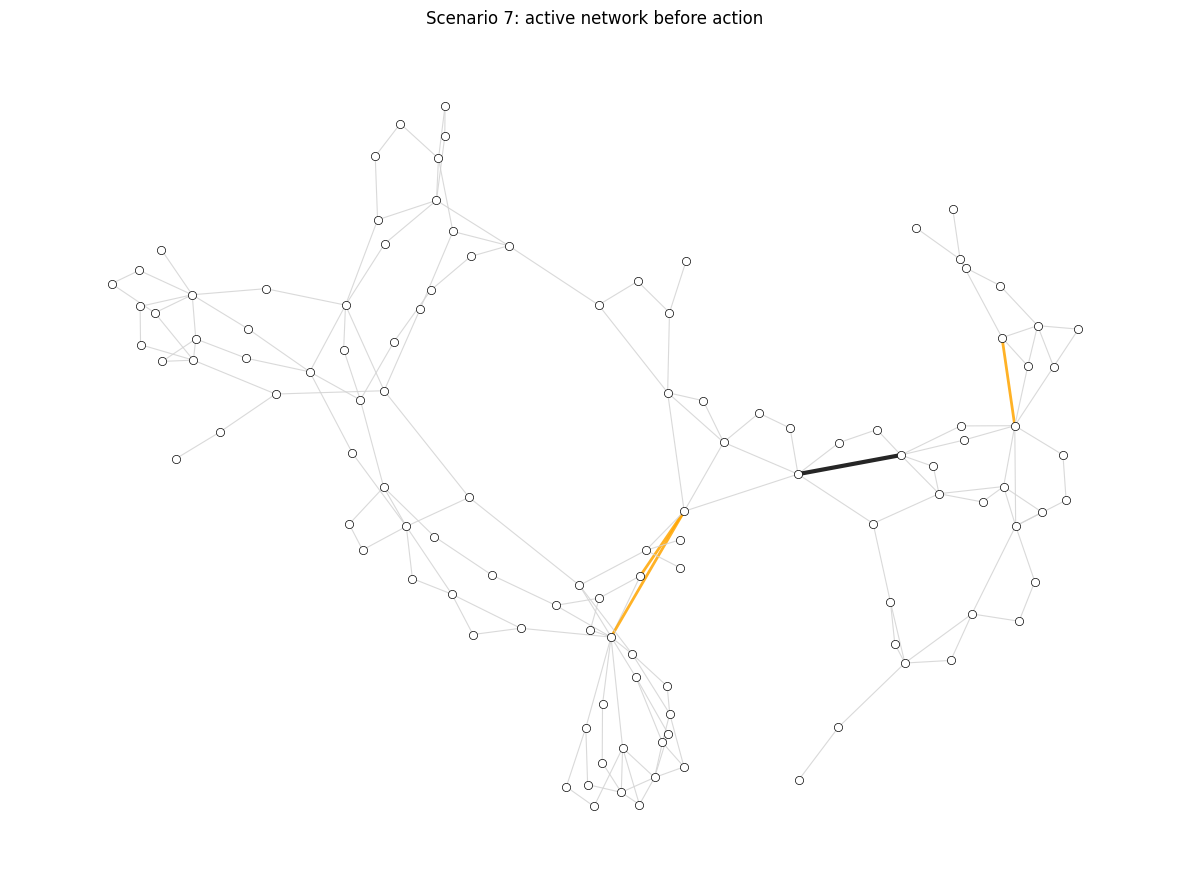

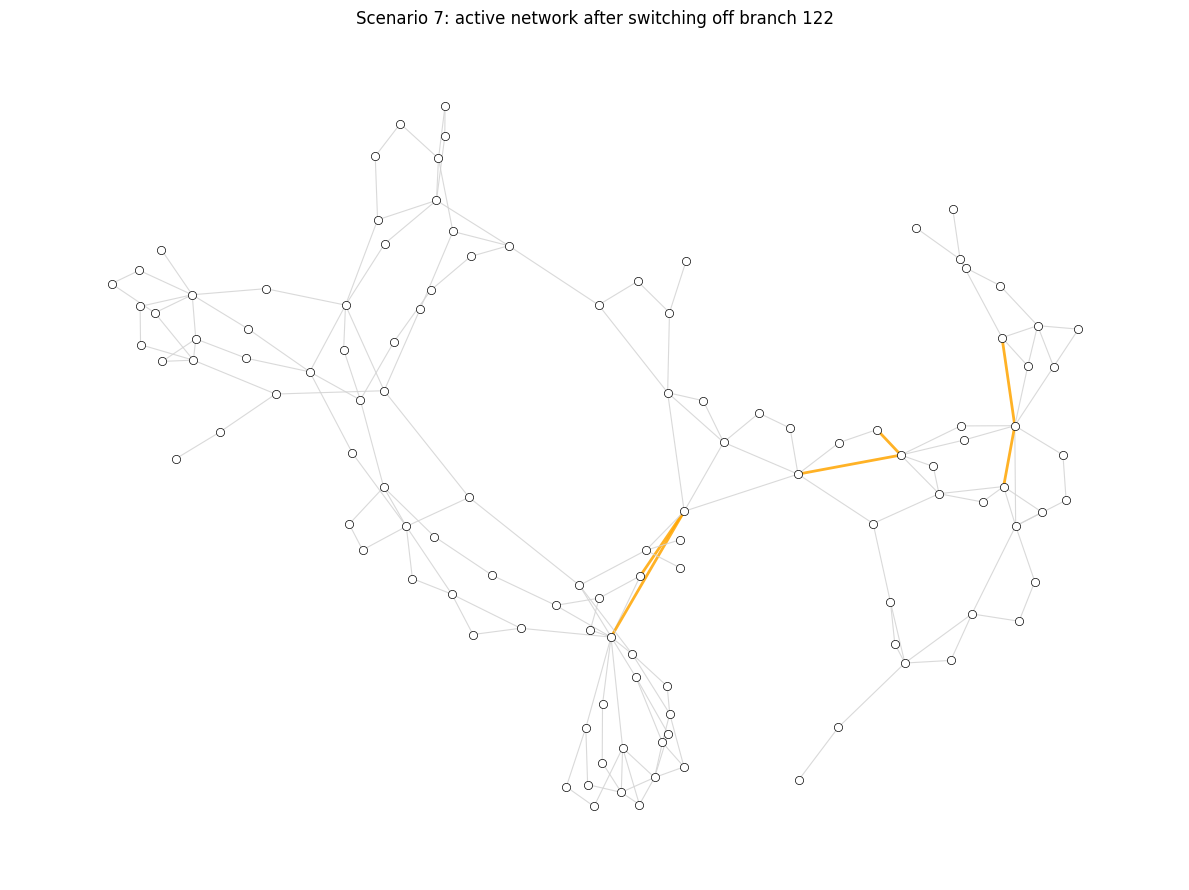

In [16]:
def draw_grid_graph(graph, pos, title, highlighted_branch_id=None):
    edge_colors = []
    edge_widths = []

    for _, _, data in graph.edges(data=True):
        color, width = edge_style(data["loading_percent"])

        if highlighted_branch_id is not None and data.get("branch_id") == highlighted_branch_id:
            color = "black"
            width = 3.0

        edge_colors.append(color)
        edge_widths.append(width)

    plt.figure(figsize=(12, 9))

    nx.draw_networkx_nodes(
        graph,
        pos,
        node_size=35,
        node_color="white",
        edgecolors="black",
        linewidths=0.5,
    )

    nx.draw_networkx_edges(
        graph,
        pos,
        edge_color=edge_colors,
        width=edge_widths,
        alpha=0.85,
    )

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


draw_grid_graph(
    G_before,
    pos,
    title=f"Scenario {SCENARIO_ID}: active network before action",
    highlighted_branch_id=BRANCH_ID,
)

draw_grid_graph(
    G_after,
    pos,
    title=f"Scenario {SCENARIO_ID}: active network after switching off branch {BRANCH_ID}",
    highlighted_branch_id=None,
)

## 8. Какие ветви были наиболее перегружены

In [17]:
def top_loaded_branches(state, n=15):
    loading_idx = BRANCH_FEATURE_COLUMNS.index("loading_percent")
    status_idx = BRANCH_FEATURE_COLUMNS.index("br_status")

    rows = []
    for pos, branch_id in enumerate(state.branch_ids):
        status = float(state.branch_features[pos, status_idx])
        if status <= 0:
            continue

        rows.append(
            {
                "branch_id": int(branch_id),
                "branch_pos": int(pos),
                "from_bus": int(state.edge_index[0, pos]),
                "to_bus": int(state.edge_index[1, pos]),
                "loading_percent": float(state.branch_features[pos, loading_idx]),
            }
        )

    return pd.DataFrame(rows).sort_values("loading_percent", ascending=False).head(n)


print("Top loaded branches before action:")
display(top_loaded_branches(state_before, n=15))

print("Top loaded branches after action:")
display(top_loaded_branches(state_after, n=15))

Top loaded branches before action:


,branch_id,branch_pos,from_bus,to_bus,loading_percent
122,122,122,76,79,145.065521
105,105,105,48,68,108.135345
104,104,104,46,68,100.921883
161,162,162,99,102,100.000000
153,154,154,93,99,98.021965
37,37,37,25,29,73.846428
20,20,20,14,16,72.574921
8,8,8,8,9,72.022118
118,118,118,68,76,70.552017
6,6,6,7,8,70.234726


Top loaded branches after action:


,branch_id,branch_pos,from_bus,to_bus,loading_percent
122,123,123,76,79,113.173172
123,124,124,78,79,109.717606
105,105,105,48,68,108.145782
152,154,154,93,99,103.593277
104,104,104,46,68,100.910393
160,162,162,99,102,100.000000
121,121,121,77,78,93.165108
120,120,120,76,77,79.871780
37,37,37,25,29,73.861649
146,148,148,81,95,73.472618


## 9. Reward landscape для выбранного сценария

Этот график показывает, какие действия были хорошими и плохими для выбранного сценария.

,scenario_id,action_id,action_type,branch_id,reward,done,before_max_loading,after_max_loading,before_total_overload,after_total_overload,before_num_overloaded,after_num_overloaded,before_num_hard_overloaded,after_num_hard_overloaded
32,7,123,switch_off_branch,122.0,170.615881,False,145.065516,113.173170,54.122749,35.540230,3,5,1,0
45,7,67,switch_off_branch,66.0,13.300044,False,145.065516,145.522265,54.122749,50.401619,3,2,1,1
44,7,66,switch_off_branch,65.0,13.300044,False,145.065516,145.522265,54.122749,50.401619,3,2,1,1
39,7,119,switch_off_branch,118.0,8.956394,False,145.065516,145.522265,54.122749,52.562950,3,2,1,1
55,7,139,switch_off_branch,138.0,6.055528,False,145.065516,143.939100,54.122749,52.972633,3,3,1,1
47,7,31,switch_off_branch,30.0,2.230541,False,145.065516,145.522265,54.122749,50.955109,3,3,1,1
31,7,0,do_nothing,NaN,0.000000,False,145.065516,145.065516,54.122749,54.122749,3,3,1,1
60,7,12,switch_off_branch,11.0,-5.265321,False,145.065516,145.522265,54.122749,54.677376,3,3,1,1
59,7,10,switch_off_branch,9.0,-5.620620,False,145.065516,145.522265,54.122749,54.854095,3,3,1,1
51,7,11,switch_off_branch,10.0,-6.181681,False,145.065516,145.522265,54.122749,54.929153,3,3,1,1


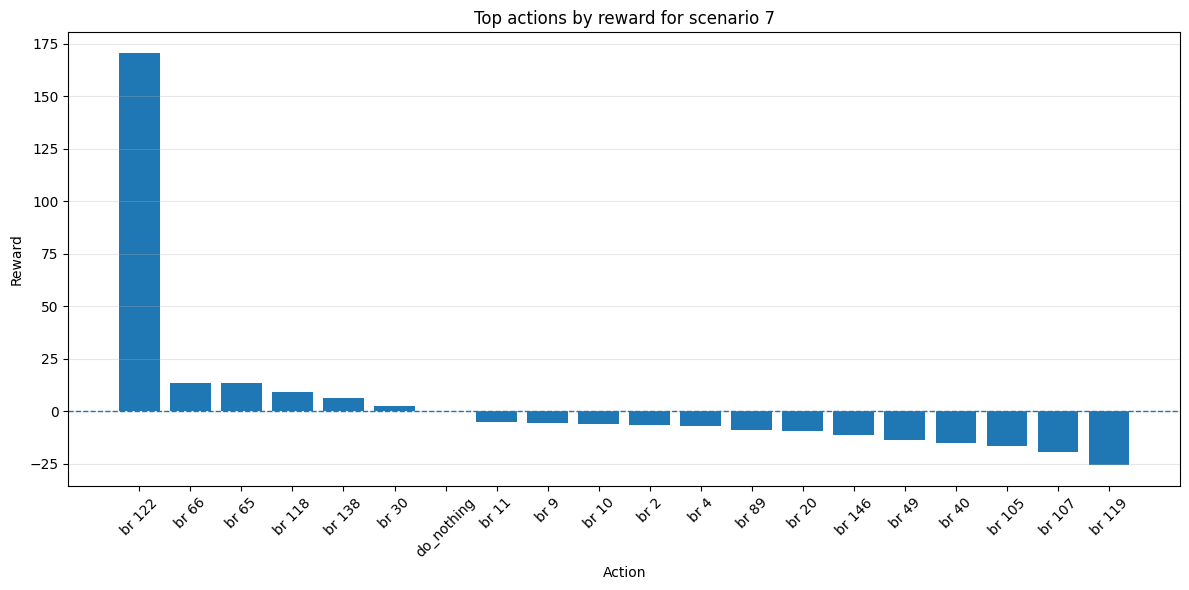

In [18]:
scenario_transitions = transitions[transitions["scenario_id"] == SCENARIO_ID].copy()
scenario_transitions = scenario_transitions.sort_values("reward", ascending=False)

display(scenario_transitions[cols].head(15))

plot_actions = scenario_transitions.head(20).copy()
plot_actions["action_label"] = plot_actions.apply(
    lambda row: "do_nothing" if row["action_type"] == "do_nothing" else f"br {int(row['branch_id'])}",
    axis=1,
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(plot_actions["action_label"], plot_actions["reward"])
ax.axhline(0.0, linestyle="--", linewidth=1)

ax.set_title(f"Top actions by reward for scenario {SCENARIO_ID}")
ax.set_xlabel("Action")
ax.set_ylabel("Reward")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Что показывает этот notebook

Если всё работает правильно, ты должен увидеть:

1. какие сценарии имеют перегрузки;
2. какие topology switching actions дают положительный reward;
3. как меняется max loading до/после действия;
4. какие ветви остаются перегруженными;
5. как выглядит активная топология сети до и после переключения.

Следующий естественный шаг после этого notebook - сохранить `state` tensors в `.npz` и сделать первый supervised warm-start dataset:

```text
state -> best_action
```

Это будет стартовая точка для GNN policy/value network перед MCTS/RL.